Dimensiones iniciales de la matriz regional (con ruido): (23, 6)
Unidades regionales retenidas tras el filtrado definitivo: 20 de 24.

Estructura final de la matriz de trabajo libre de artefactos administrativos:
Unidades regionales consolidadas tras filtrado de representatividad: 20 de 24.

Matriz final de trabajo libre de ruido administrativo:
              total_casos  edad_media  prop_femenino  tasa_con_signos  \
departamento                                                            
AMAZONAS            16805   27.886939       0.527046         0.077715   
ANCASH              37661   33.904579       0.549189         0.080879   
AYACUCHO             9946   30.803934       0.520310         0.038307   
CAJAMARCA           29711   29.245889       0.531419         0.113426   
CALLAO               8138   32.322455       0.537847         0.090194   

              tasa_grave  semana_pico  
departamento                           
AMAZONAS        0.002916         20.0  
ANCASH          0.00

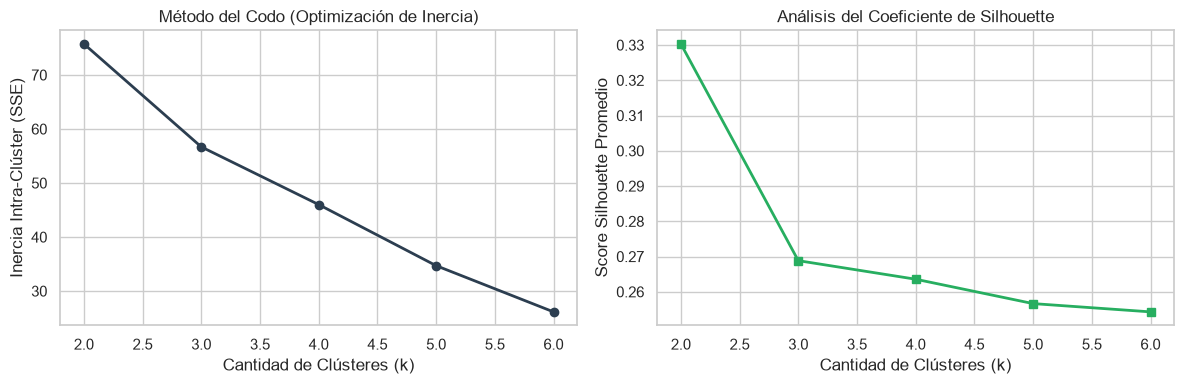

Hiperparámetro estructurado óptimo por maximización de Silhouette: K = 2
 EVALUACIÓN DE ARQUITECTURAS NO SUPERVISADAS (K = 2)
• Arquitectura: K-Means      | Coef. Silhouette: 0.3303 | Índice Davies-Bouldin: 1.0851
• Arquitectura: Jerárquico   | Coef. Silhouette: 0.3291 | Índice Davies-Bouldin: 0.9964


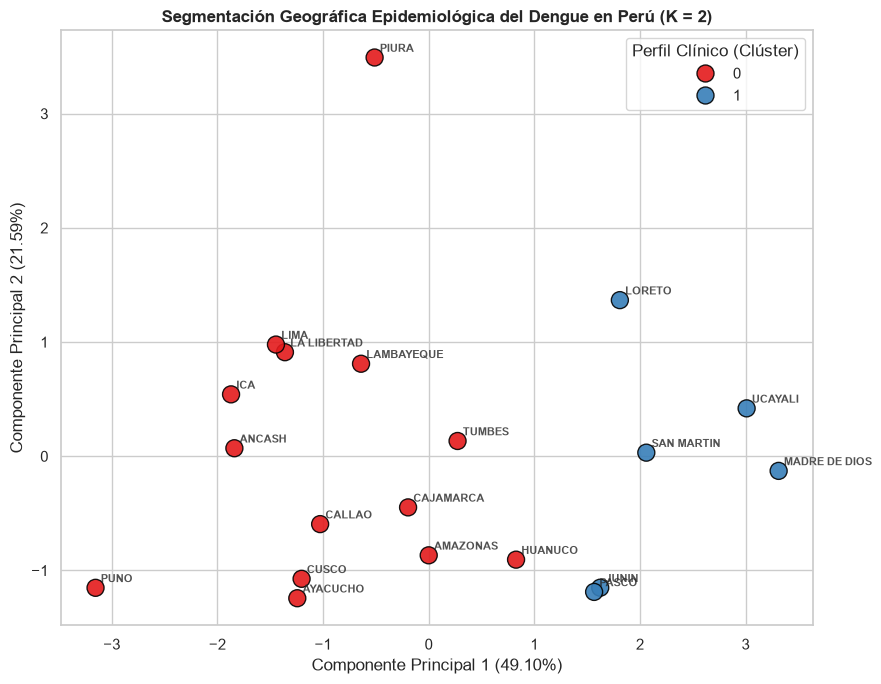


 CARACTERIZACIÓN OPERATIVA DE LOS PERFILES EPIDEMIOLÓGICOS GENERADOS
         total_casos  edad_media  prop_femenino  tasa_con_signos  tasa_grave  \
cluster                                                                        
0         54451.5714     31.5957         0.5379           0.0816      0.0028   
1         44507.5000     27.6077         0.5176           0.1490      0.0058   

         semana_pico  
cluster               
0            17.0000  
1            39.6667  


In [1]:
# ==============================================================================
# REFACTORIZACIÓN METODOLÓGICA COMPLETA DE 04_Clustering.ipynb
# ==============================================================================

# ------------------------------------------------------------------------------
# CELDA 1: CONTROL DE ENTORNO, LIBRERÍAS Y CONFIGURACIÓN ESTÉTICA
# ------------------------------------------------------------------------------
import sys
import os
sys.path.append('../src')  # Inyección del path local para acceder a src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Configuración estética institucional para publicación
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# ------------------------------------------------------------------------------
# CELDA 2: CARGA, LIMPIEZA Y CONSTRUCCIÓN DEL PERFIL DE CARACTERÍSTICAS
# ------------------------------------------------------------------------------
from data import cargar_crudo, normalizar_edad, ORDEN_SEVERIDAD

# 1. Carga e integración del preprocesamiento base individual
df = cargar_crudo()
df = normalizar_edad(df)

# 2. Tipado estricto de variables temporales y mapeo ordinal de severidad
df['semana'] = pd.to_numeric(df['semana'], errors='coerce')
df['severidad'] = df['enfermedad'].map(ORDEN_SEVERIDAD)

# 3. Purga de registros inconsistentes o nulos
df = df[df['sexo'].isin(['M', 'F'])]
df = df[df['edad_anios'].between(0, 110)]
df = df.dropna(subset=['severidad', 'edad_anios', 'semana', 'departamento'])

# 4. Construcción de la matriz agregada de características por departamento
perfil = df.groupby('departamento').agg(
    total_casos=('severidad', 'size'),
    edad_media=('edad_anios', 'mean'),
    prop_femenino=('sexo', lambda s: (s == 'F').mean()),
    tasa_con_signos=('severidad', lambda s: (s >= 1).mean()),
    tasa_grave=('severidad', lambda s: (s == 2).mean()),
    semana_pico=('semana', lambda s: float(s.value_counts().idxmax())),
)

print(f"Dimensiones iniciales de la matriz regional (con ruido): {perfil.shape}")

# ==============================================================================
# FILTRO DE UMBRAL MÍNIMO DE REPRESENTATIVIDAD ESTADÍSTICA (FASE 3 DEL PLAN)
# ==============================================================================
# Mitigamos el sesgo institucional de reporte removiendo departamentos 
# con una masa crítica inferior a 100 casos acumulados en 25 años.
UMBRAL_CASOS_HISTORICOS = 100
perfil_filtrado = perfil[perfil['total_casos'] >= UMBRAL_CASOS_HISTORICOS].copy()

print(f"Unidades regionales retenidas tras el filtrado definitivo: {perfil_filtrado.shape[0]} de 24.")
print("\nEstructura final de la matriz de trabajo libre de artefactos administrativos:")
perfil_filtrado

# ------------------------------------------------------------------------------
# CELDA 3: FILTRO CRÍTICO DE UMBRAL DE REPRESENTATIVIDAD ESTADÍSTICA
# ------------------------------------------------------------------------------
# Eliminamos unidades geográficas atípicas con nula infraestructura de reporte (Moquegua y Apurímac)
# para evitar centroides colapsados y clústeres triviales degenerados.
UMBRAL_CASOS_HISTORICOS = 100
perfil_filtrado = perfil[perfil['total_casos'] >= UMBRAL_CASOS_HISTORICOS].copy()

print(f"Unidades regionales consolidadas tras filtrado de representatividad: {perfil_filtrado.shape[0]} de 24.")
print("\nMatriz final de trabajo libre de ruido administrativo:")
print(perfil_filtrado.head())

# ------------------------------------------------------------------------------
# CELDA 4: NORMALIZACIÓN MULTIVARIANTE DE CARACTERÍSTICAS
# ------------------------------------------------------------------------------
# Escalado de varianza unitaria para neutralizar la dominancia del volumen de casos continuos
X_scaled = StandardScaler().fit_transform(perfil_filtrado.values)
print('Matriz normalizada escalada para el procesamiento:', X_scaled.shape)

# ------------------------------------------------------------------------------
# CELDA 5: OPTIMIZACIÓN DEL NÚMERO DE CLÚSTERES (MÉTODO DE CODO Y SILHOUETTE)
# ------------------------------------------------------------------------------
ks = range(2, 7)
inercias, silhouettes = [], []

for k in ks:
    km_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inercias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_test.labels_))

# Renderizado de curvas de validación interna
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inercias, 'o-', color='#2c3e50', lw=2)
ax1.set_title('Método del Codo (Optimización de Inercia)')
ax1.set_xlabel('Cantidad de Clústeres (k)')
ax1.set_ylabel('Inercia Intra-Clúster (SSE)')

ax2.plot(list(ks), silhouettes, 's-', color='#27ae60', lw=2)
ax2.set_title('Análisis del Coeficiente de Silhouette')
ax2.set_xlabel('Cantidad de Clústeres (k)')
ax2.set_ylabel('Score Silhouette Promedio')
plt.tight_layout()
plt.show()

# Selección matemática automatizada del K óptimo
K_OPTIMO = list(ks)[int(np.argmax(silhouettes))]
print(f"Hiperparámetro estructurado óptimo por maximización de Silhouette: K = {K_OPTIMO}")

# ------------------------------------------------------------------------------
# CELDA 6: AJUSTE DE MODELOS Y EVALUACIÓN CRUZADA DE MÉTRICAS NO SUPERVISADAS
# ------------------------------------------------------------------------------
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
jerarquico_final = AgglomerativeClustering(n_clusters=K_OPTIMO).fit(X_scaled)

print("=" * 80)
print(f" EVALUACIÓN DE ARQUITECTURAS NO SUPERVISADAS (K = {K_OPTIMO})")
print("=" * 80)
for nombre, labels in [('K-Means', kmeans_final.labels_), ('Jerárquico', jerarquico_final.labels_)]:
    s_score = silhouette_score(X_scaled, labels)
    db_index = davies_bouldin_score(X_scaled, labels)
    print(f"• Arquitectura: {nombre:<12} | Coef. Silhouette: {s_score:.4f} | Índice Davies-Bouldin: {db_index:.4f}")
print("=" * 80)

# Asignación de clústeres definitivos al DataFrame filtrado
perfil_filtrado['cluster'] = kmeans_final.labels_

# ------------------------------------------------------------------------------
# CELDA 7: REDUCCIÓN DE DIMENSIONALIDAD (PCA) Y VISUALIZACIÓN ESPACIAL
# ------------------------------------------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1], 
    hue=perfil_filtrado['cluster'],
    palette='Set1', s=150, edgecolor='black', alpha=0.9
)

# Inyección de etiquetas geográficas sobre los vectores proyectados
for i, dep in enumerate(perfil_filtrado.index):
    plt.annotate(dep, (coords[i, 0] + 0.05, coords[i, 1] + 0.05), fontsize=8, weight='bold', alpha=0.8)

plt.title(f'Segmentación Geográfica Epidemiológica del Dengue en Perú (K = {K_OPTIMO})', fontsize=12, weight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Perfil Clínico (Clúster)', loc='best')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# CELDA 8: INTERPRETACIÓN DE LOS PERFILES MEDIOS DE SALUD PÚBLICA
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print(" CARACTERIZACIÓN OPERATIVA DE LOS PERFILES EPIDEMIOLÓGICOS GENERADOS")
print("=" * 80)
perfiles_medios = perfil_filtrado.groupby('cluster').mean()
print(perfiles_medios.round(4))
print("=" * 80)